# Landslide Detection Using Satellite Imagery

This is the project code. We're using conv2d for now.


### Installation of required libraries and basic setup

In [1]:
!pip install tensorflow

In [2]:
!pip install matplotlib

In [1]:
import pandas as pd
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf

In [2]:
import os

# Step 1: Change to the desired directory
# Replace with the path to your local folder
os.chdir(r'C:\Users\Nitro v15\Desktop\Minor Project\archive')

### Testing the dataset 

In [3]:
# Testing the dataset 
path_single = r"TrainData\img\image_2000.h5"
path_single_mask = r'TrainData\mask\mask_2000.h5'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.42230782933301864..3.9737369685644146].


Keys in the HDF5 file: ['img']
Input data shape: (128, 128, 14)


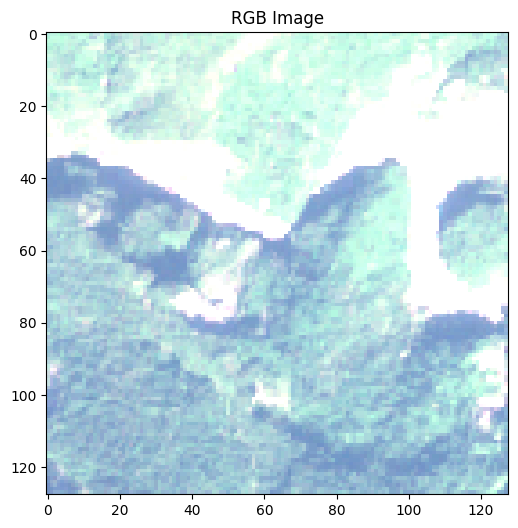

NDVI data shape: (128, 128)
f_data shape: (1, 128, 128, 3)


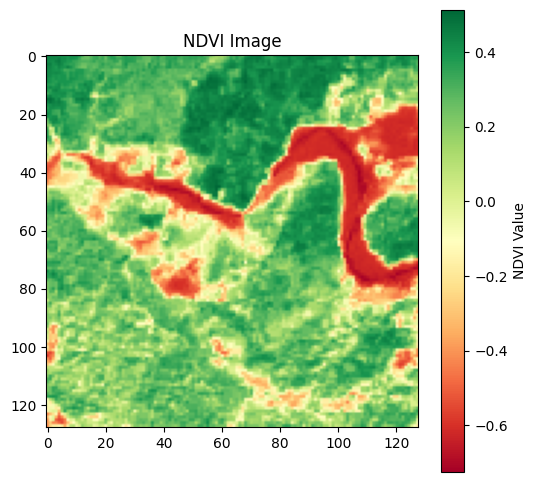

In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Assuming `path_single` is defined as the path to your .h5 file
f_data = np.zeros((1, 128, 128, 3))

with h5py.File(path_single, 'r') as hdf:
    ls = list(hdf.keys())
    print("Keys in the HDF5 file:", ls)
    
    # Access the dataset 'img'
    data = np.array(hdf.get('img'))
    print("Input data shape:", data.shape)
    
    # Display the RGB image
    plt.figure(figsize=(6, 6))
    plt.title("RGB Image")
    plt.imshow(data[:, :, 3:0:-1])  # RGB visualization
    plt.show()  # Display the plot
    
    # Extract individual bands
    data_red = data[:, :, 3]
    data_green = data[:, :, 2]
    data_blue = data[:, :, 1]
    data_nir = data[:, :, 7]
    
    # Compute NDVI (with division by zero handling)
    data_ndvi = np.divide(
        data_nir - data_red, 
        np.add(data_nir, data_red), 
        out=np.zeros_like(data_nir),  # Default value if division by zero
        where=np.add(data_nir, data_red) != 0  # Avoid division by zero
    )
    
    # Add NDVI and other bands to f_data
    f_data[0, :, :, 0] = data_ndvi
    f_data[0, :, :, 1] = data[:, :, 12]  # Assuming valid index
    f_data[0, :, :, 2] = data[:, :, 13]  # Assuming valid index
    
    print("NDVI data shape:", data_ndvi.shape)
    print("f_data shape:", f_data.shape)
    
    # Plot NDVI
    plt.figure(figsize=(6, 6))
    plt.title("NDVI Image")
    plt.imshow(data_ndvi, cmap='RdYlGn')  # Use a colormap for NDVI visualization
    plt.colorbar(label="NDVI Value")
    plt.show()  # Display the plot


Keys in the HDF5 file: ['mask']
Input data shape: (128, 128)
Landslide


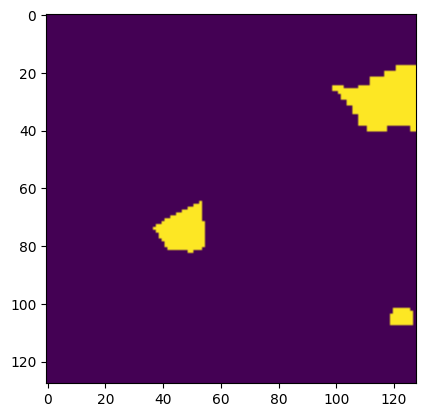

In [5]:


# Load the .h5 mask file

with h5py.File(path_single_mask) as hdf:
    ls = list(hdf.keys())
    print("Keys in the HDF5 file:", ls)
    
    # Extract the mask data
    data = np.array(hdf.get('mask'))
    print("Input data shape:", data.shape)

    # Generate labels (1 for landslide detected, 0 for non-detected)
    labels = np.where(data == 1, 1, 0)  # Landslide = 1, Non-detected = 0

    # Check if any landslides are detected (i.e., if there are any 1s in the mask)
    if np.any(labels == 1):
        print("Landslide")
    else:
        print("No Landslide")
    
    # Optional: Display the mask
    plt.imshow(data)  # Display the mask
    plt.show()



# Now, `labels` will contain the 1s and 0s for landslide detection.


### Using all dataset

In [6]:
path_single = r"TrainData/img/image_10.h5"
path_single_mask = r'TrainData/mask/mask_1.h5'
TRAIN_PATH = r"TrainData/img/*.h5"
TRAIN_MASK = r'TrainData/mask/*.h5'

TRAIN_XX = np.zeros((3799, 128, 128, 6))
TRAIN_YY = np.zeros((3799, 128, 128, 1))
all_train = sorted(glob.glob(TRAIN_PATH))
all_mask = sorted(glob.glob(TRAIN_MASK))

### Train with RGB, NDVI, DEM, and Slope 


In [15]:
!pip install tensorflow-gpu


  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [39 lines of output]
      Traceback (most recent call last):
        File "C:\Users\Public\Anaconda\envs\newenv\lib\site-packages\packaging\requirements.py", line 36, in __init__
          parsed = _parse_requirement(requirement_string)
        File "C:\Users\Public\Anaconda\envs\newenv\lib\site-packages\packaging\_parser.py", line 62, in parse_requirement
          return _parse_requirement(Tokenizer(source, rules=DEFAULT_RULES))
        File "C:\Users\Public\Anaconda\envs\newenv\lib\site-packages\packaging\_parser.py", line 80, in _parse_requirement
          url, specifier, marker = _parse_requirement_details(tokenizer)
        File "C:\Users\Public\Anaconda\envs\newenv\lib\site-packages\packaging\_parser.py", line 124, in _parse_requirement_details
          marker = _parse_requirement_marker(
        File "C:\Users\Public\Anaconda\envs\newenv\lib\site-packages\pa

In [16]:
pip show tensorflow


Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\public\anaconda\envs\newenv\lib\site-packages
Requires: tensorflow-intel
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [7]:
import tensorflow as tf

#print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))


Available GPUs: []


In [8]:
for i, (img, mask) in enumerate(zip(all_train, all_mask)):
    print(i, img, mask)
    with h5py.File(img) as hdf:
        ls = list(hdf.keys())
        data = np.array(hdf.get('img'))

        # assign 0 for the nan value
        data[np.isnan(data)] = 0.000001

        # to normalize the data 
        mid_rgb = data[:, :, 1:4].max() / 2.0
        mid_slope = data[:, :, 12].max() / 2.0
        mid_elevation = data[:, :, 13].max() / 2.0

        # ndvi calculation
        data_red = data[:, :, 3]
        data_nir = data[:, :, 7]
        data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))
        
        # final array
        TRAIN_XX[i, :, :, 0] = 1 - data[:, :, 3] / mid_rgb  #RED
        TRAIN_XX[i, :, :, 1] = 1 - data[:, :, 2] / mid_rgb #GREEN
        TRAIN_XX[i, :, :, 2] = 1 - data[:, :, 1] / mid_rgb #BLUE
        TRAIN_XX[i, :, :, 3] = data_ndvi #NDVI
        TRAIN_XX[i, :, :, 4] = 1 - data[:, :, 12] / mid_slope #SLOPE
        TRAIN_XX[i, :, :, 5] = 1 - data[:, :, 13] / mid_elevation #ELEVATION
    
    
    with h5py.File(mask) as hdf:
        ls = list(hdf.keys())
        data=np.array(hdf.get('mask'))
        TRAIN_YY[i, :, :, 0] = data
    

0 TrainData/img\image_1.h5 TrainData/mask\mask_1.h5
1 TrainData/img\image_10.h5 TrainData/mask\mask_10.h5
2 TrainData/img\image_100.h5 TrainData/mask\mask_100.h5
3 TrainData/img\image_1000.h5 TrainData/mask\mask_1000.h5
4 TrainData/img\image_1001.h5 TrainData/mask\mask_1001.h5
5 TrainData/img\image_1002.h5 TrainData/mask\mask_1002.h5
6 TrainData/img\image_1003.h5 TrainData/mask\mask_1003.h5
7 TrainData/img\image_1004.h5 TrainData/mask\mask_1004.h5
8 TrainData/img\image_1005.h5 TrainData/mask\mask_1005.h5
9 TrainData/img\image_1006.h5 TrainData/mask\mask_1006.h5
10 TrainData/img\image_1007.h5 TrainData/mask\mask_1007.h5
11 TrainData/img\image_1008.h5 TrainData/mask\mask_1008.h5
12 TrainData/img\image_1009.h5 TrainData/mask\mask_1009.h5
13 TrainData/img\image_101.h5 TrainData/mask\mask_101.h5
14 TrainData/img\image_1010.h5 TrainData/mask\mask_1010.h5
15 TrainData/img\image_1011.h5 TrainData/mask\mask_1011.h5
16 TrainData/img\image_1012.h5 TrainData/mask\mask_1012.h5
17 TrainData/img\imag

C:\Users\Nitro v15\AppData\Local\Temp\ipykernel_54452\3444182847.py:25: RuntimeWarning: invalid value encountered in divide
  TRAIN_XX[i, :, :, 4] = 1 - data[:, :, 12] / mid_slope #SLOPE


1683 TrainData/img\image_2513.h5 TrainData/mask\mask_2513.h5
1684 TrainData/img\image_2514.h5 TrainData/mask\mask_2514.h5
1685 TrainData/img\image_2515.h5 TrainData/mask\mask_2515.h5
1686 TrainData/img\image_2516.h5 TrainData/mask\mask_2516.h5
1687 TrainData/img\image_2517.h5 TrainData/mask\mask_2517.h5
1688 TrainData/img\image_2518.h5 TrainData/mask\mask_2518.h5
1689 TrainData/img\image_2519.h5 TrainData/mask\mask_2519.h5
1690 TrainData/img\image_252.h5 TrainData/mask\mask_252.h5
1691 TrainData/img\image_2520.h5 TrainData/mask\mask_2520.h5
1692 TrainData/img\image_2521.h5 TrainData/mask\mask_2521.h5
1693 TrainData/img\image_2522.h5 TrainData/mask\mask_2522.h5
1694 TrainData/img\image_2523.h5 TrainData/mask\mask_2523.h5
1695 TrainData/img\image_2524.h5 TrainData/mask\mask_2524.h5
1696 TrainData/img\image_2525.h5 TrainData/mask\mask_2525.h5
1697 TrainData/img\image_2526.h5 TrainData/mask\mask_2526.h5
1698 TrainData/img\image_2527.h5 TrainData/mask\mask_2527.h5
1699 TrainData/img\image_2

C:\Users\Nitro v15\AppData\Local\Temp\ipykernel_54452\3444182847.py:18: RuntimeWarning: invalid value encountered in divide
  data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))


2273 TrainData/img\image_3044.h5 TrainData/mask\mask_3044.h5
2274 TrainData/img\image_3045.h5 TrainData/mask\mask_3045.h5
2275 TrainData/img\image_3046.h5 TrainData/mask\mask_3046.h5
2276 TrainData/img\image_3047.h5 TrainData/mask\mask_3047.h5
2277 TrainData/img\image_3048.h5 TrainData/mask\mask_3048.h5
2278 TrainData/img\image_3049.h5 TrainData/mask\mask_3049.h5
2279 TrainData/img\image_305.h5 TrainData/mask\mask_305.h5
2280 TrainData/img\image_3050.h5 TrainData/mask\mask_3050.h5
2281 TrainData/img\image_3051.h5 TrainData/mask\mask_3051.h5
2282 TrainData/img\image_3052.h5 TrainData/mask\mask_3052.h5
2283 TrainData/img\image_3053.h5 TrainData/mask\mask_3053.h5
2284 TrainData/img\image_3054.h5 TrainData/mask\mask_3054.h5
2285 TrainData/img\image_3055.h5 TrainData/mask\mask_3055.h5
2286 TrainData/img\image_3056.h5 TrainData/mask\mask_3056.h5
2287 TrainData/img\image_3057.h5 TrainData/mask\mask_3057.h5
2288 TrainData/img\image_3058.h5 TrainData/mask\mask_3058.h5
2289 TrainData/img\image_3

### Testing min, max values in train data

In [9]:
# TRAIN_XX_n = TRAIN_XX / TRAIN_XX.max()
TRAIN_XX[np.isnan(TRAIN_XX)] = 0.000001
print(TRAIN_XX.min(), TRAIN_XX.max(), TRAIN_YY.min(), TRAIN_YY.max())

-1.0 1.0 0.0 1.0


### Custom loss function (Dice Loss)

In [10]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    return 1 - (2. * intersection + smooth) / (union + smooth)


### Visualization of the training data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7836734693877552].


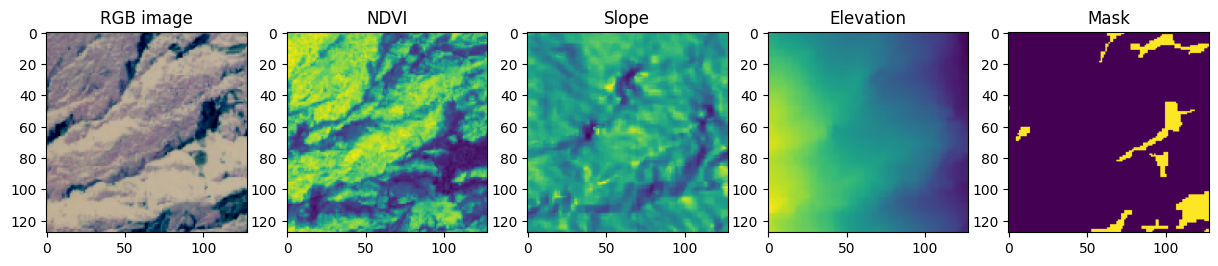

In [11]:
img=234
fig,(ax1,ax2, ax3, ax4, ax5)= plt.subplots(1,5,figsize=(15,10))


ax1.set_title("RGB image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Elevation")
ax5.set_title("Mask")
ax1.imshow(TRAIN_XX[img, :, :, 0:3])
ax2.imshow(TRAIN_XX[img, :, :, 3])
ax3.imshow(TRAIN_XX[img, :, :, 4])
ax4.imshow(TRAIN_XX[img, :, :, 5])
ax5.imshow(TRAIN_YY[img, :, :, 0])

### Validation split

In [12]:
from sklearn.model_selection import train_test_split

# Split the data
x_train, x_valid, y_train, y_valid = train_test_split(TRAIN_XX, TRAIN_YY, test_size=0.2, shuffle= True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7305841924398626].


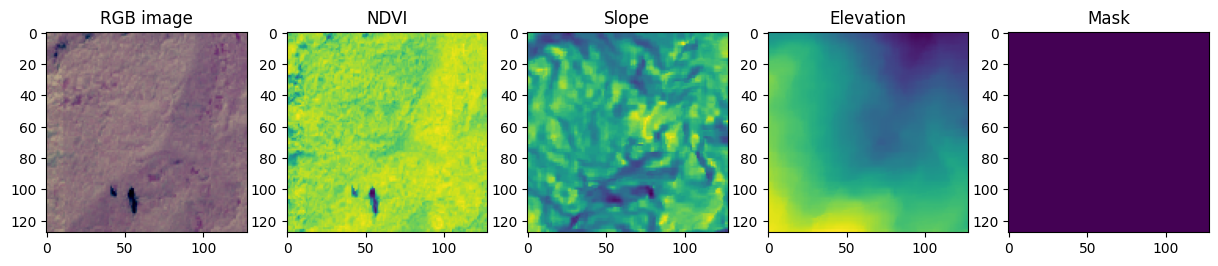

In [13]:
img=1451
fig,(ax1,ax2, ax3, ax4, ax5)= plt.subplots(1,5,figsize=(15,10))

ax1.set_title("RGB image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Elevation")
ax5.set_title("Mask")
ax1.imshow(x_train[img, :, :, 0:3])
ax2.imshow(x_train[img, :, :, 3])
ax3.imshow(x_train[img, :, :, 4])
ax4.imshow(x_train[img, :, :, 5])
ax5.imshow(y_train[img, :, :, 0])

In [14]:
x_train.shape, y_train.shape

((3039, 128, 128, 6), (3039, 128, 128, 1))

In [15]:
# to release some memory, delete the unnecessary variable
del TRAIN_XX
del TRAIN_YY
del all_train
del all_mask 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8043098427489808].


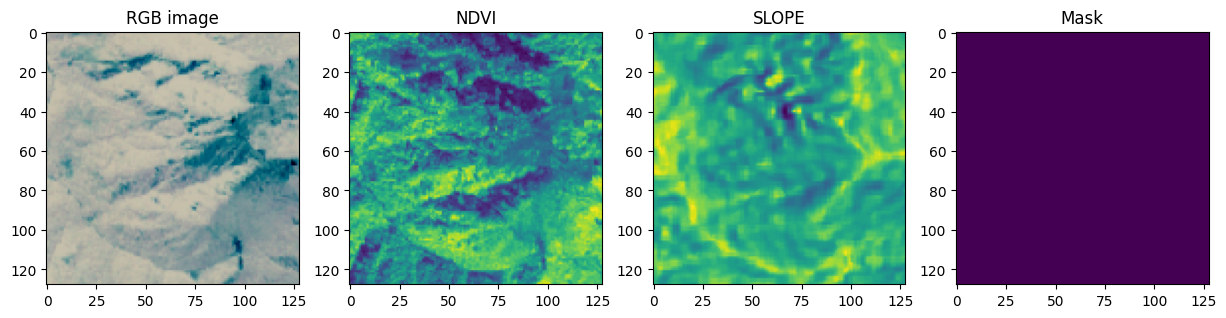

In [16]:
img=1540

fig,(ax1,ax2, ax3, ax4)= plt.subplots(1,4,figsize=(15,10))


ax1.set_title("RGB image")
ax2.set_title("NDVI")
ax3.set_title("SLOPE")
ax4.set_title("Mask")
ax1.imshow(x_train[img, :, :, 0:3])
ax2.imshow(x_train[img, :, :, 3])
ax3.imshow(x_train[img, :, :, 4])
ax4.imshow(y_train[img, :, :, 0])

### Unet Model

In [17]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.layers import BatchNormalization

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def f1_m(y_true, y_pred):
    p = precision_m(y_true, y_pred)
    r = recall_m(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return (2. * intersection + smooth) / (union + smooth)



def unet_model(IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS):
    inputs = tf.keras.layers.Input((IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS))

    # Contraction path
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(inputs)
    c1 = BatchNormalization()(c1)  # Adding BatchNormalization
    c1 = tf.keras.layers.Activation('relu')(c1)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c1)
    c1 = BatchNormalization()(c1)  # Adding BatchNormalization
    c1 = tf.keras.layers.Activation('relu')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(p1)
    c2 = BatchNormalization()(c2)  # Adding BatchNormalization
    c2 = tf.keras.layers.Activation('relu')(c2)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c2)
    c2 = BatchNormalization()(c2)  # Adding BatchNormalization
    c2 = tf.keras.layers.Activation('relu')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(p2)
    c3 = BatchNormalization()(c3)  # Adding BatchNormalization
    c3 = tf.keras.layers.Activation('relu')(c3)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c3)
    c3 = BatchNormalization()(c3)  # Adding BatchNormalization
    c3 = tf.keras.layers.Activation('relu')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(p3)
    c4 = BatchNormalization()(c4)  # Adding BatchNormalization
    c4 = tf.keras.layers.Activation('relu')(c4)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c4)
    c4 = BatchNormalization()(c4)  # Adding BatchNormalization
    c4 = tf.keras.layers.Activation('relu')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(p4)
    c5 = BatchNormalization()(c5)  # Adding BatchNormalization
    c5 = tf.keras.layers.Activation('relu')(c5)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c5)
    c5 = BatchNormalization()(c5)  # Adding BatchNormalization
    c5 = tf.keras.layers.Activation('relu')(c5)

    # Expansive path
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(u6)
    c6 = BatchNormalization()(c6)  # Adding BatchNormalization
    c6 = tf.keras.layers.Activation('relu')(c6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c6)
    c6 = BatchNormalization()(c6)  # Adding BatchNormalization
    c6 = tf.keras.layers.Activation('relu')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(u7)
    c7 = BatchNormalization()(c7)  # Adding BatchNormalization
    c7 = tf.keras.layers.Activation('relu')(c7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c7)
    c7 = BatchNormalization()(c7)  # Adding BatchNormalization
    c7 = tf.keras.layers.Activation('relu')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(u8)
    c8 = BatchNormalization()(c8)  # Adding BatchNormalization
    c8 = tf.keras.layers.Activation('relu')(c8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c8)
    c8 = BatchNormalization()(c8)  # Adding BatchNormalization
    c8 = tf.keras.layers.Activation('relu')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(u9)
    c9 = BatchNormalization()(c9)  # Adding BatchNormalization
    c9 = tf.keras.layers.Activation('relu')(c9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation=None, kernel_initializer='he_normal', padding='same')(c9)
    c9 = BatchNormalization()(c9)  # Adding BatchNormalization
    c9 = tf.keras.layers.Activation('relu')(c9)

    # Output layer
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    # Build the model
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='binary_crossentropy', 
              metrics=['accuracy', f1_m, precision_m, recall_m, dice_coefficient])


    return model



In [19]:
# Assuming the function `unet_model` is already defined
model = unet_model(128, 128, 6)

# Display model summary
# model.summary()

# Define callbacks
checkpointer = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", 
    monitor="val_f1_m", 
    verbose=1, 
    save_best_only=True, 
    mode="max"
)

# Uncomment if early stopping is needed
# earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_m', patience=10, verbose=1, mode='max')

callbacks = [
    # earlyStopping,  # Uncomment if early stopping is needed
    checkpointer
]

# Train the model
history = model.fit(
    x_train, 
    y_train, 
    batch_size=16,
    epochs=100,
    verbose=2,
    validation_data=(x_valid, y_valid),
    callbacks=callbacks
)

# Save the final model
model.save("model_save.keras")


Epoch 1/100


c:\Users\Public\Anaconda\envs\newenv\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 6))
  warnings.warn(msg)



Epoch 1: val_f1_m improved from -inf to 0.37557, saving model to best_model.keras
190/190 - 84s - 444ms/step - accuracy: 0.9548 - dice_coefficient: 0.0664 - f1_m: 0.3466 - loss: 0.2922 - precision_m: 0.5508 - recall_m: 0.3510 - val_accuracy: 0.9794 - val_dice_coefficient: 0.0687 - val_f1_m: 0.3756 - val_loss: 0.2412 - val_precision_m: 0.6199 - val_recall_m: 0.2832
Epoch 2/100

Epoch 2: val_f1_m did not improve from 0.37557
190/190 - 56s - 296ms/step - accuracy: 0.9816 - dice_coefficient: 0.1099 - f1_m: 0.4650 - loss: 0.1071 - precision_m: 0.6878 - recall_m: 0.3898 - val_accuracy: 0.9780 - val_dice_coefficient: 0.0693 - val_f1_m: 0.1357 - val_loss: 0.0916 - val_precision_m: 0.9302 - val_recall_m: 0.0762
Epoch 3/100

Epoch 3: val_f1_m improved from 0.37557 to 0.40443, saving model to best_model.keras
190/190 - 82s - 432ms/step - accuracy: 0.9823 - dice_coefficient: 0.1500 - f1_m: 0.5192 - loss: 0.0678 - precision_m: 0.6904 - recall_m: 0.4521 - val_accuracy: 0.9821 - val_dice_coefficient

In [20]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.saving import register_keras_serializable

# Registering custom metrics for serialization
@register_keras_serializable()
def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

@register_keras_serializable()
def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return true_positives / (predicted_positives + K.epsilon())

@register_keras_serializable()
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

@register_keras_serializable()
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1, 2, 3])
    union = K.sum(K.abs(y_true), axis=[1, 2, 3]) + K.sum(K.abs(y_pred), axis=[1, 2, 3])
    return (2. * intersection + smooth) / (union + smooth)


In [22]:
from tensorflow.keras.models import load_model

# Load the model with custom metrics
model = load_model(
    "best_model.keras", 
    custom_objects={
        "f1_m": f1_m, 
        "precision_m": precision_m, 
        "recall_m": recall_m, 
        "dice_coefficient": dice_coefficient
    }
)


In [18]:
from tqdm import tqdm


In [23]:

# Define metrics including Dice Coefficient
metrics = ["Loss", "Accuracy", "F1-Score", "Precision", "Recall", "Dice Coefficient"]
results = []

# Evaluate with progress bar
with tqdm(total=len(x_valid), desc="Evaluating", unit="samples") as pbar:
    loss, accuracy, f1_score, precision, recall, dice_coeff = model.evaluate(x_valid, y_valid, verbose=0)
    results = [loss, accuracy, f1_score, precision, recall, dice_coeff]
    pbar.update(len(x_valid))  # Update progress bar after evaluation

# Print Results
for metric, value in zip(metrics, results):
    print(f"{metric}: {value:.4f}")

Evaluating: 100%|██████████| 760/760 [00:06<00:00, 119.61samples/s]

Loss: 0.0220
Accuracy: 0.9910
F1-Score: 0.7816
Precision: 0.8196
Recall: 0.7483
Dice Coefficient: 0.3325


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter  # For alternative smoothing

# Smoothing function using Simple Moving Average (SMA)
def smooth_curve(values, window=5):
    """Apply moving average to smooth a curve."""
    return np.convolve(values, np.ones(window)/window, mode='valid')

# Extract history
history_dict = history.history



NameError: name 'history' is not defined

In [25]:
import numpy as np
import matplotlib.pyplot as plt

NameError: name 'history_dict' is not defined

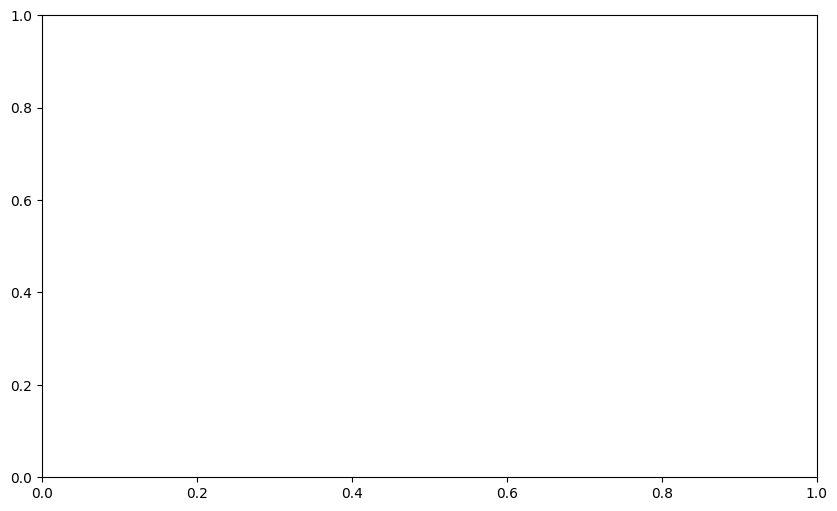

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

# Accuracy
ax.plot(smooth_curve(history_dict['accuracy']), label='train')
ax.plot(smooth_curve(history_dict['val_accuracy']), label='validation')
ax.set_title('Model Accuracy vs. Epoch')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.legend(loc='upper left')

plt.show()

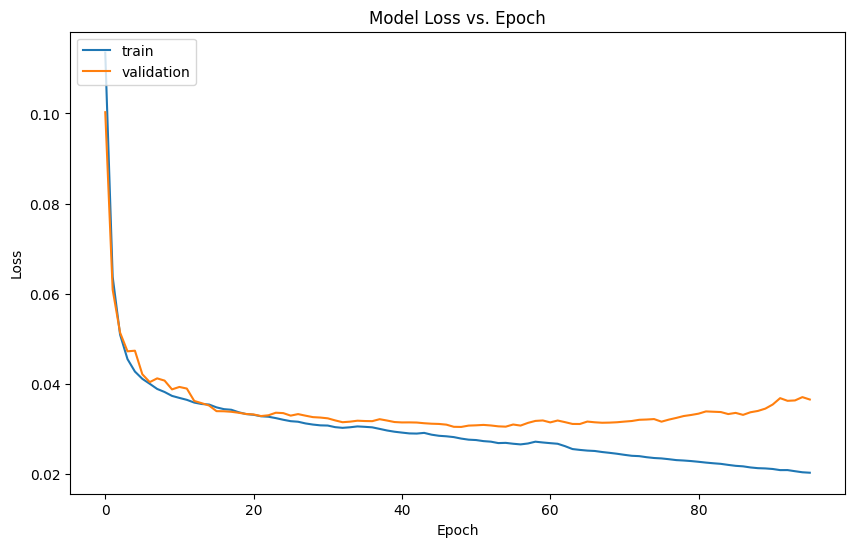

In [30]:
# Plot Loss vs Epoch
fig, ax11 = plt.subplots(figsize=(10, 6))

# Loss

ax11.plot(smooth_curve(history_dict['loss']), label='train')
ax11.plot(smooth_curve(history_dict['val_loss']), label='validation')
ax11.title.set_text('Model Loss vs. Epoch')
ax11.set_ylabel('Loss')
ax11.set_xlabel('Epoch')
ax11.legend(loc='upper left')

plt.show()

### Validation

In [27]:
threshold = 0.6
pred_img = model.predict(x_valid)
pred_img = (pred_img > threshold).astype(np.uint8)

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7367624810892587].


Prediction for image 119: Landslide
Ground truth label for image 119: Landslide


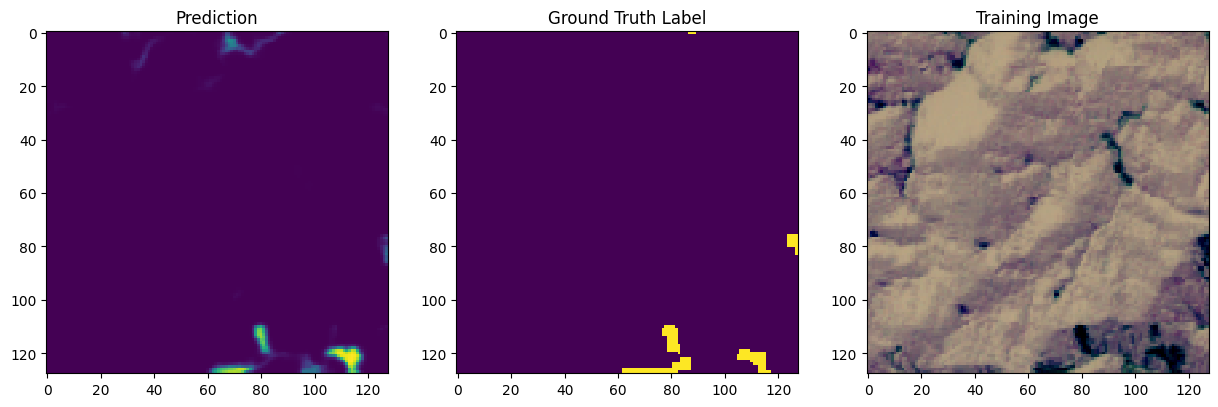

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Select the image index to display
img = 119

# Predict the segmentation mask for the input image
pred_img = model.predict(x_valid)  # Model prediction on validation data

# Thresholding the prediction to get binary values (0: No Landslide, 1: Landslide)
thresholded_pred = (pred_img[img, :, :, 0] > 0.6).astype(int)  # For binary segmentation

# Check if there is any landslide (pixel value 1) in the predicted mask
landslide_detected = np.any(thresholded_pred == 1)

# Determine the prediction label (Landslide or No Landslide)
prediction_label = "Landslide" if landslide_detected else "No Landslide"

# Get the ground truth label for the image
ground_truth_label = "Landslide" if np.any(y_valid[img, :, :, 0] == 1) else "No Landslide"

# Print the prediction and the label separately
print(f"Prediction for image {img}: {prediction_label}")
print(f"Ground truth label for image {img}: {ground_truth_label}")

# Create subplots for displaying images
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 10))

# Display the prediction (adjusted for better clarity)
ax1.imshow(pred_img[img, :, :, 0], interpolation='none')
ax1.set_title("Prediction")

# Display the ground truth label
ax2.imshow(y_valid[img, :, :, 0], interpolation='none')
ax2.set_title("Ground Truth Label")

# Display the training image (color image)
ax3.imshow(x_valid[img, :, :, 0:3], interpolation='none')
ax3.set_title('Training Image')

# Show the plot
plt.show()


In [ ]:
!pip install opencv-python


   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
    --------------------------------------- 0.8/39.5 MB 6.7 MB/s eta 0:00:06
   - -------------------------------------- 1.8/39.5 MB 6.7 MB/s eta 0:00:06
   ---- ----------------------------------- 4.7/39.5 MB 8.4 MB/s eta 0:00:05
   ------ --------------------------------- 6.8/39.5 MB 9.1 MB/s eta 0:00:04
   --------- ------------------------------ 9.4/39.5 MB 9.5 MB/s eta 0:00:04
   ----------- ---------------------------- 11.5/39.5 MB 9.8 MB/s eta 0:00:03
   -------------- ------------------------- 13.9/39.5 MB 9.8 MB/s eta 0:00:03
   ---------------- ----------------------- 16.5/39.5 MB 10.2 MB/s eta 0:00:03
   ------------------- -------------------- 19.1/39.5 MB 10.5 MB/s eta 0:00:02
   --------------------- ------------------ 21.0/39.5 MB 10.4 MB/s eta 0:00:02
   ---------------------- ----------------- 22.5/39.5 MB 10.0 MB/s eta 0:00:02
   ------------------------ --------------- 24.6/39.5 MB 10.1 MB/s eta 0:

### CONFUSION MATRIX

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

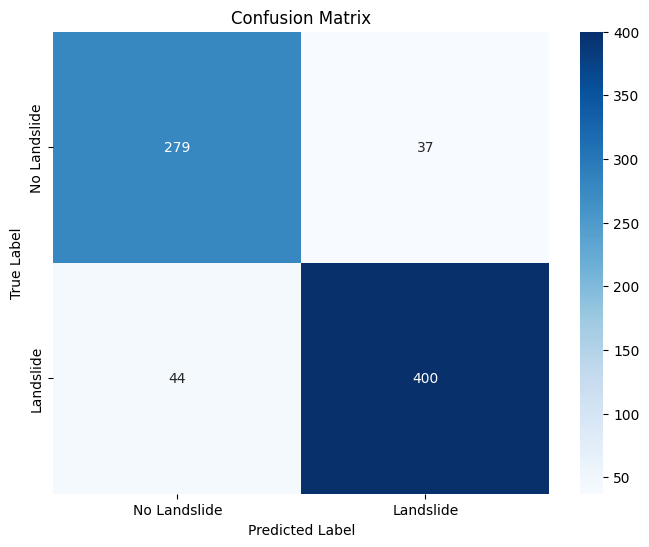

Confusion Matrix:
[[279  37]
 [ 44 400]]


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to hold the predicted and ground truth labels
y_pred = []
y_true = []

# Iterate through the validation set and generate the predictions and ground truth labels
for img in range(len(x_valid)):
    # Predict the segmentation mask for the current image
    pred_img = model.predict(np.expand_dims(x_valid[img], axis=0))  # Predict for the current image

    # Threshold the prediction to get binary values (0: No Landslide, 1: Landslide)
    thresholded_pred = (pred_img[0, :, :, 0] > 0.6).astype(int)  # For binary segmentation

    # Determine the prediction label (1 for Landslide, 0 for No Landslide)
    landslide_pred = np.any(thresholded_pred == 1)  # If any pixel in the mask is 1, it's a landslide
    y_pred.append(landslide_pred)

    # Get the ground truth label for the image
    landslide_true = np.any(y_valid[img, :, :, 0] == 1)  # Check if there's any pixel labeled 1 (Landslide)
    y_true.append(landslide_true)

# Convert the lists to numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Landslide", "Landslide"], yticklabels=["No Landslide", "Landslide"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Optionally, print the confusion matrix
print("Confusion Matrix:")
print(cm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

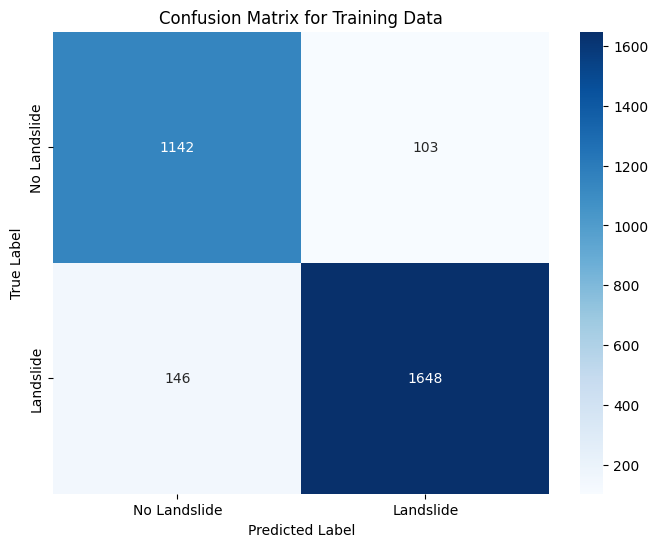

Confusion Matrix for Training Data:
[[1142  103]
 [ 146 1648]]


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to hold the predicted and ground truth labels for training data
y_pred_train = []
y_true_train = []

# Iterate through the training set and generate the predictions and ground truth labels
for img in range(len(x_train)):
    # Predict the segmentation mask for the current image
    pred_img = model.predict(np.expand_dims(x_train[img], axis=0))  # Predict for the current image

    # Threshold the prediction to get binary values (0: No Landslide, 1: Landslide)
    thresholded_pred = (pred_img[0, :, :, 0] > 0.6).astype(int)  # For binary segmentation

    # Determine the prediction label (1 for Landslide, 0 for No Landslide)
    landslide_pred = np.any(thresholded_pred == 1)  # If any pixel in the mask is 1, it's a landslide
    y_pred_train.append(landslide_pred)

    # Get the ground truth label for the image
    landslide_true = np.any(y_train[img, :, :, 0] == 1)  # Check if there's any pixel labeled 1 (Landslide)
    y_true_train.append(landslide_true)

# Convert the lists to numpy arrays
y_pred_train = np.array(y_pred_train)
y_true_train = np.array(y_true_train)

# Generate the confusion matrix for the training data
cm_train = confusion_matrix(y_true_train, y_pred_train)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=["No Landslide", "Landslide"], yticklabels=["No Landslide", "Landslide"])
plt.title("Confusion Matrix for Training Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Optionally, print the confusion matrix
print("Confusion Matrix for Training Data:")
print(cm_train)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

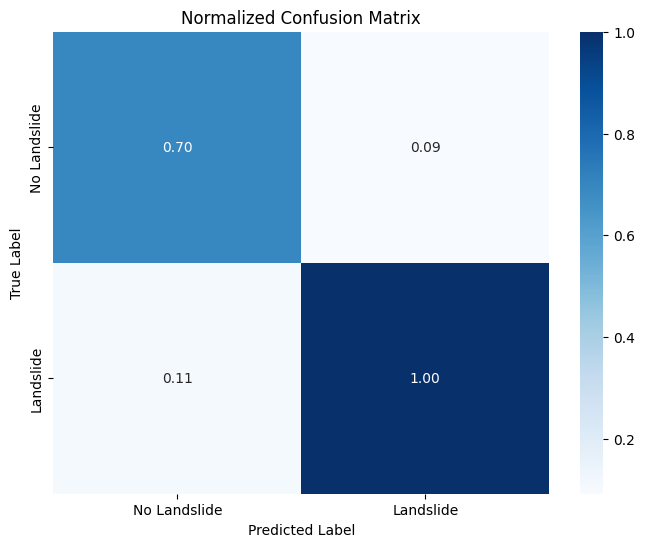

Normalized Confusion Matrix:
[[0.6975 0.0925]
 [0.11   1.    ]]


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to hold the predicted and ground truth labels
y_pred = []
y_true = []

# Iterate through the validation set and generate the predictions and ground truth labels
for img in range(len(x_valid)):
    # Predict the segmentation mask for the current image
    pred_img = model.predict(np.expand_dims(x_valid[img], axis=0))  # Predict for the current image

    # Threshold the prediction to get binary values (0: No Landslide, 1: Landslide)
    thresholded_pred = (pred_img[0, :, :, 0] > 0.6).astype(int)  # For binary segmentation

    # Determine the prediction label (1 for Landslide, 0 for No Landslide)
    landslide_pred = np.any(thresholded_pred == 1)  # If any pixel in the mask is 1, it's a landslide
    y_pred.append(landslide_pred)

    # Get the ground truth label for the image
    landslide_true = np.any(y_valid[img, :, :, 0] == 1)  # Check if there's any pixel labeled 1 (Landslide)
    y_true.append(landslide_true)

# Convert the lists to numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix by dividing by the maximum value in the matrix
cm_normalized = cm / cm.max()  # This scales the matrix between 0 and 1

# Plot the normalized confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=["No Landslide", "Landslide"], yticklabels=["No Landslide", "Landslide"])
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Optionally, print the normalized confusion matrix
print("Normalized Confusion Matrix:")
print(cm_normalized)

### DICE COEFFICIENT FOR INDIVIDUAL IMAGE

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7152255639097744].


Prediction for image 169: Landslide
Ground truth label for image 169: Landslide
Dice Coefficient for image 169: 0.4813


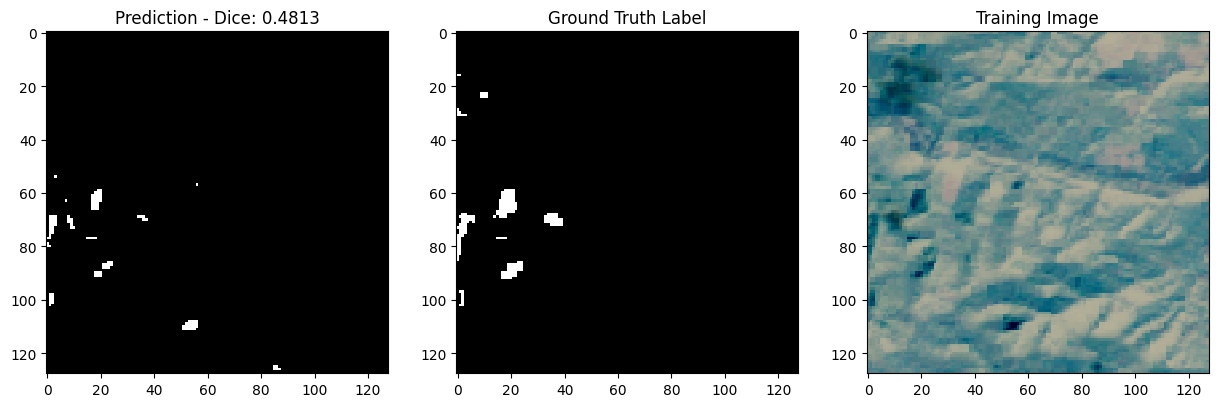

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# Select the image index to display
img = 169

# Predict the segmentation mask for the input image
pred_img = model.predict(x_valid)  # Model prediction on validation data

# Thresholding the prediction to get binary values (0: No Landslide, 1: Landslide)
thresholded_pred = (pred_img[img, :, :, 0] > 0.6).astype(int)  # For binary segmentation

# Ground truth mask for the selected image
gt_mask = (y_valid[img, :, :, 0] == 1).astype(int)  # Binary ground truth mask

# Calculate the Dice Coefficient for the current image
intersection = np.sum(thresholded_pred * gt_mask)  # True positives (correctly predicted landslides)
dice_coefficient = (2 * intersection) / (np.sum(thresholded_pred) + np.sum(gt_mask))

# Check if there is any landslide (pixel value 1) in the predicted mask
landslide_detected = np.any(thresholded_pred == 1)

# Determine the prediction label (Landslide or No Landslide)
prediction_label = "Landslide" if landslide_detected else "No Landslide"

# Get the ground truth label for the image
ground_truth_label = "Landslide" if np.any(gt_mask == 1) else "No Landslide"

# Print the prediction, ground truth, and Dice coefficient
print(f"Prediction for image {img}: {prediction_label}")
print(f"Ground truth label for image {img}: {ground_truth_label}")
print(f"Dice Coefficient for image {img}: {dice_coefficient:.4f}")

# Create subplots for displaying images and the Dice Coefficient
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 10))

# Display the prediction (adjusted for better clarity)
ax1.imshow(thresholded_pred, cmap='gray', interpolation='none')
ax1.set_title(f"Prediction - Dice: {dice_coefficient:.4f}")

# Display the ground truth label
ax2.imshow(gt_mask, cmap='gray', interpolation='none')
ax2.set_title("Ground Truth Label")

# Display the training image (color image)
ax3.imshow(x_valid[img, :, :, 0:3], interpolation='none')
ax3.set_title('Training Image')

# Show the plot
plt.show()


### Test data 

In [80]:
import glob
import h5py
import numpy as np

validation_url = r'C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\*.h5'
img_val = sorted(glob.glob(validation_url))

VAL_XX = np.zeros((245, 128, 128, 6))
mask_name = []

for i, img in enumerate(img_val):
    print(i, img)
    mask_name.append(img.split('/')[-1].replace('image', 'mask'))
    
    with h5py.File(img) as hdf:
        # Check the keys to ensure we're accessing the correct dataset
        print(f"Keys in {img}: {list(hdf.keys())}")
        
        data = np.array(hdf.get('img'), dtype=np.float32)  # Ensure data is in float32
        
        # Print the shape of the data to ensure it's 3D
        print(f"Data shape: {data.shape}")
        
        # Ensure the data is 3D before proceeding
        if len(data.shape) == 3:
            # Handle NaN values
            data[np.isnan(data)] = 0.000001

            # Normalize the data 
            mid_rgb = data[:, :, 1:4].max() / 2.0
            mid_slope = data[:, :, 12].max() / 2.0
            mid_elevation = data[:, :, 13].max() / 2.0

            # NDVI calculation
            data_red = data[:, :, 3]
            data_nir = data[:, :, 7]
            data_ndvi = np.divide(data_nir - data_red, np.add(data_nir, data_red))
            
            # Final array population
            VAL_XX[i, :, :, 0] = 1 - data[:, :, 3] / mid_rgb  # RED
            VAL_XX[i, :, :, 1] = 1 - data[:, :, 2] / mid_rgb  # GREEN
            VAL_XX[i, :, :, 2] = 1 - data[:, :, 1] / mid_rgb  # BLUE
            VAL_XX[i, :, :, 3] = data_ndvi  # NDVI
            VAL_XX[i, :, :, 4] = 1 - data[:, :, 13] / mid_slope  # SLOPE
            VAL_XX[i, :, :, 5] = 1 - data[:, :, 13] / mid_elevation  # ELEVATION
        else:
            print(f"Skipping image {img} due to unexpected shape: {data.shape}")


0 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_1.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_1.h5: ['img']
Data shape: (128, 128, 14)
1 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_10.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_10.h5: ['img']
Data shape: (128, 128, 14)
2 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_100.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_100.h5: ['img']
Data shape: (128, 128, 14)
3 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_101.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_101.h5: ['img']
Data shape: (128, 128, 14)
4 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_102.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_102.h5: ['img']
Data shape: (128, 128, 14)
5 C:\Users\Nitro

C:\Users\Nitro v15\AppData\Local\Temp\ipykernel_39476\463510778.py:37: RuntimeWarning: invalid value encountered in divide
  data_ndvi = np.divide(data_nir - data_red, np.add(data_nir, data_red))


Data shape: (128, 128, 14)
184 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_44.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_44.h5: ['img']
Data shape: (128, 128, 14)
185 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_45.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_45.h5: ['img']
Data shape: (128, 128, 14)
186 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_46.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_46.h5: ['img']
Data shape: (128, 128, 14)
187 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_47.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_47.h5: ['img']
Data shape: (128, 128, 14)
188 C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_48.h5
Keys in C:\Users\Nitro v15\Desktop\Minor Project\archive\ValidData\img\image_48.h5: ['img']
Data shape

### Prediction for testing data

In [81]:
threshold = 0.6
pred_img = model.predict(VAL_XX)
pred_img = (pred_img > threshold).astype(np.uint8)
pred_img.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step


(245, 128, 128, 1)

### Visualization of test image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7961335778236389].


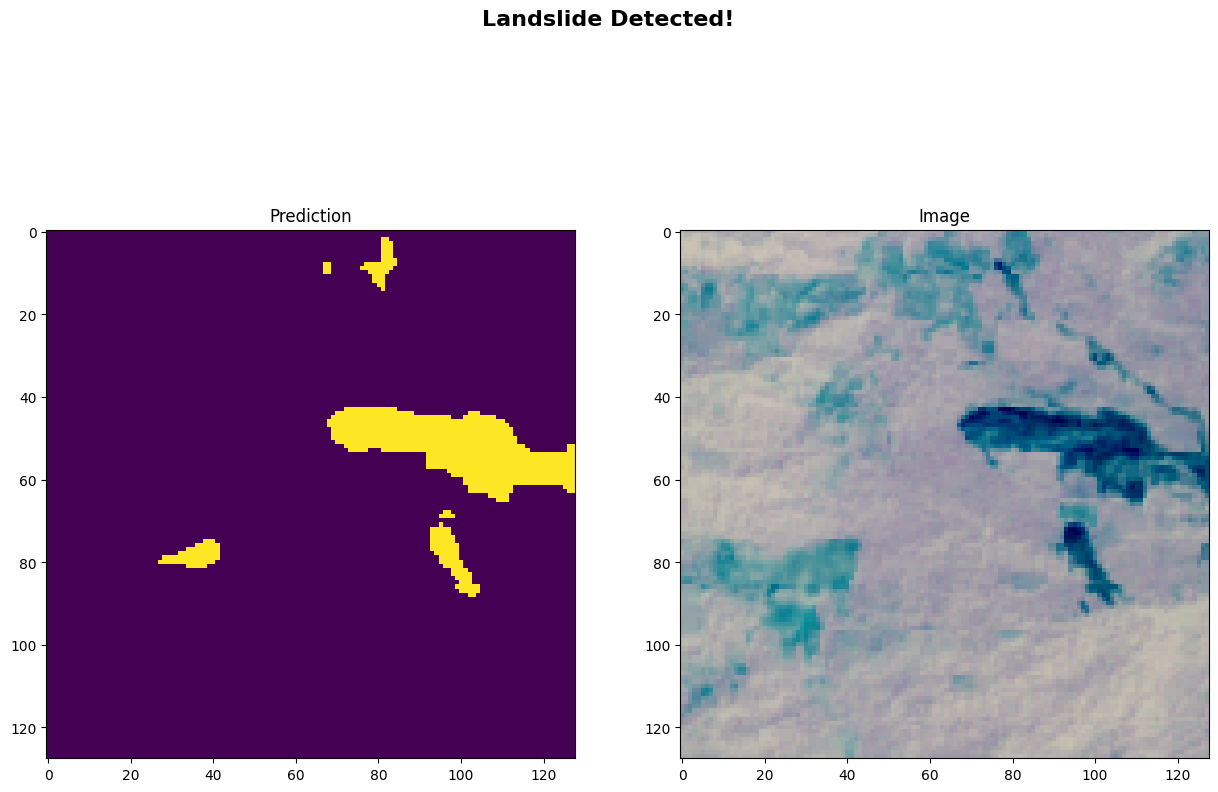

In [82]:
import numpy as np
import matplotlib.pyplot as plt

img = 128  # Select the image index

# Check if landslide is detected (at least one pixel in pred_img is 1)
is_landslide = np.any(pred_img[img, :, :, 0] == 1)

# Define label text based on landslide presence
label_text = "Landslide Detected!" if is_landslide else "No Landslide detected"

# Plot the images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

# Show the predicted mask
ax1.imshow(pred_img[img, :, :, 0])
ax1.set_title("Prediction")

# Show the input image
ax2.imshow(VAL_XX[img, :, :, 0:3])
ax2.set_title('Image')



# Add text annotation for landslide detection result
fig.suptitle(label_text, fontsize=16, fontweight="bold", color="Black")

plt.show()



Conv2D done
remaining: finetuning, sb conv and streamlit 